**Loading the Libraries**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8')

**Loading Dataset**

In [4]:
df = pd.read_csv("../Dataset/gastric_cancer_detection_dataset.csv")
df.head()

,age,gender,ethnicity,geographical_location,family_history,smoking_habits,alcohol_consumption,helicobacter_pylori_infection,dietary_habits,existing_conditions,...,elmmo,microcosm,miranda,mirdb,pictar,pita,targetscan,predicted.sum,all.sum,label
0,43,Male,Ethnicity_A,Other,1,0,0,0,Low_Salt,Chronic Gastritis,...,0.187003,0.786422,0.204816,0.561920,0.438175,0.283603,0.928244,4.324299,7.666791,0
1,86,Female,Ethnicity_B,California,1,0,0,1,High_Salt,Diabetes,...,0.493322,0.963989,0.498041,0.985585,0.144609,0.375375,0.103573,7.967674,1.483280,0
2,68,Male,Ethnicity_A,California,0,1,1,0,High_Salt,NaN,...,0.573560,0.666896,0.540388,0.905853,0.827279,0.350915,0.166878,3.748651,3.046783,0
3,57,Female,Ethnicity_A,Other,0,0,0,1,High_Salt,Chronic Gastritis,...,0.261399,0.949488,0.134170,0.429935,0.935231,0.794704,0.867036,5.478298,8.811307,0
4,33,Male,Ethnicity_A,California,0,1,1,0,High_Salt,Diabetes,...,0.754478,0.263164,0.876767,0.650832,0.337669,0.427492,0.915804,1.809181,0.394632,0


In [5]:
# basic information of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 212354 entries, 0 to 212353
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   age                            212354 non-null  int64  
 1   gender                         212354 non-null  str    
 2   ethnicity                      212354 non-null  str    
 3   geographical_location          212354 non-null  str    
 4   family_history                 212354 non-null  int64  
 5   smoking_habits                 212354 non-null  int64  
 6   alcohol_consumption            212354 non-null  int64  
 7   helicobacter_pylori_infection  212354 non-null  int64  
 8   dietary_habits                 212354 non-null  str    
 9   existing_conditions            169868 non-null  str    
 10  endoscopic_images              212354 non-null  str    
 11  biopsy_results                 212354 non-null  str    
 12  ct_scan                        212354 non

In [6]:
# describing the dataset to note consistency of value
display(df.describe())
df.describe(include='all')

,age,family_history,smoking_habits,alcohol_consumption,helicobacter_pylori_infection,target_entrez,target_ensembl,diana_microt,elmmo,microcosm,miranda,mirdb,pictar,pita,targetscan,predicted.sum,all.sum,label
count,212354.000000,212354.000000,212354.000000,212354.000000,212354.000000,212354.000000,2.123540e+05,212354.000000,2.123540e+05,212354.000000,212354.000000,212354.000000,2.123540e+05,212354.000000,212354.000000,212354.000000,212354.000000,212354.000000
mean,53.258036,0.300564,0.399154,0.499378,0.249470,5496.117332,1.499874e+06,0.500527,4.994971e-01,0.500083,0.499895,0.500125,4.989745e-01,0.501152,0.501117,5.010346,5.000085,0.098698
std,18.984419,0.458504,0.489726,0.500001,0.432707,2596.817632,2.882585e+05,0.288757,2.888452e-01,0.288491,0.288571,0.288738,2.884995e-01,0.288874,0.288678,2.884461,2.882685,0.298257
min,20.000000,0.000000,0.000000,0.000000,0.000000,1000.000000,1.000007e+06,0.000005,6.089062e-07,0.000003,0.000001,0.000013,7.743957e-07,0.000008,0.000004,0.000016,0.000081,0.000000
25%,37.000000,0.000000,0.000000,0.000000,0.000000,3252.000000,1.251177e+06,0.250034,2.486468e-01,0.249877,0.250206,0.250293,2.497943e-01,0.250322,0.251790,2.512241,2.505941,0.000000
50%,50.000000,0.000000,0.000000,0.000000,0.000000,5491.000000,1.500324e+06,0.501302,4.998040e-01,0.500498,0.499635,0.499888,4.985230e-01,0.502228,0.501814,5.018196,5.003598,0.000000
75%,69.000000,1.000000,1.000000,1.000000,0.000000,7738.000000,1.748424e+06,0.750783,7.495843e-01,0.748769,0.749075,0.749994,7.487212e-01,0.751212,0.751860,7.508878,7.493106,0.000000
max,89.000000,1.000000,1.000000,1.000000,1.000000,9999.000000,1.999998e+06,0.999998,9.999993e-01,0.999997,0.999997,1.000000,9.999986e-01,0.999993,0.999997,9.999908,9.999987,1.000000


,age,gender,ethnicity,geographical_location,family_history,smoking_habits,alcohol_consumption,helicobacter_pylori_infection,dietary_habits,existing_conditions,...,elmmo,microcosm,miranda,mirdb,pictar,pita,targetscan,predicted.sum,all.sum,label
count,212354.000000,212354,212354,212354,212354.000000,212354.000000,212354.000000,212354.000000,212354,169868,...,2.123540e+05,212354.000000,212354.000000,212354.000000,2.123540e+05,212354.000000,212354.000000,212354.000000,212354.000000,212354.000000
unique,NaN,2,3,2,NaN,NaN,NaN,NaN,2,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Male,Ethnicity_A,California,NaN,NaN,NaN,NaN,High_Salt,Chronic Gastritis,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,148706,127571,169603,NaN,NaN,NaN,NaN,169805,106309,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,53.258036,NaN,NaN,NaN,0.300564,0.399154,0.499378,0.249470,NaN,NaN,...,4.994971e-01,0.500083,0.499895,0.500125,4.989745e-01,0.501152,0.501117,5.010346,5.000085,0.098698
std,18.984419,NaN,NaN,NaN,0.458504,0.489726,0.500001,0.432707,NaN,NaN,...,2.888452e-01,0.288491,0.288571,0.288738,2.884995e-01,0.288874,0.288678,2.884461,2.882685,0.298257
min,20.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,...,6.089062e-07,0.000003,0.000001,0.000013,7.743957e-07,0.000008,0.000004,0.000016,0.000081,0.000000
25%,37.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,...,2.486468e-01,0.249877,0.250206,0.250293,2.497943e-01,0.250322,0.251790,2.512241,2.505941,0.000000
50%,50.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,...,4.998040e-01,0.500498,0.499635,0.499888,4.985230e-01,0.502228,0.501814,5.018196,5.003598,0.000000
75%,69.000000,NaN,NaN,NaN,1.000000,1.000000,1.000000,0.000000,NaN,NaN,...,7.495843e-01,0.748769,0.749075,0.749994,7.487212e-01,0.751212,0.751860,7.508878,7.493106,0.000000


In [7]:
# viewing the columns of dataset
df.columns

Index(['age', 'gender', 'ethnicity', 'geographical_location', 'family_history',
       'smoking_habits', 'alcohol_consumption',
       'helicobacter_pylori_infection', 'dietary_habits',
       'existing_conditions', 'endoscopic_images', 'biopsy_results', 'ct_scan',
       'mature_mirna_acc', 'mature_mirna_id', 'target_symbol', 'target_entrez',
       'target_ensembl', 'diana_microt', 'elmmo', 'microcosm', 'miranda',
       'mirdb', 'pictar', 'pita', 'targetscan', 'predicted.sum', 'all.sum',
       'label'],
      dtype='str')

All capitalized letter of the columns should be noted

In [8]:
df.shape

(212354, 29)

In [9]:
#finding missing values
display(df.isna().sum())

age                                  0
gender                               0
ethnicity                            0
geographical_location                0
family_history                       0
smoking_habits                       0
alcohol_consumption                  0
helicobacter_pylori_infection        0
dietary_habits                       0
existing_conditions              42486
endoscopic_images                    0
biopsy_results                       0
ct_scan                              0
mature_mirna_acc                     0
mature_mirna_id                      0
target_symbol                        0
target_entrez                        0
target_ensembl                       0
diana_microt                         0
elmmo                                0
microcosm                            0
miranda                              0
mirdb                                0
pictar                               0
pita                                 0
targetscan               

Missing values in the dataset are shown above

In [10]:
display(df.shape)

(212354, 29)

In [11]:
# checking the dataset once again for encoding
df.head()

,age,gender,ethnicity,geographical_location,family_history,smoking_habits,alcohol_consumption,helicobacter_pylori_infection,dietary_habits,existing_conditions,...,elmmo,microcosm,miranda,mirdb,pictar,pita,targetscan,predicted.sum,all.sum,label
0,43,Male,Ethnicity_A,Other,1,0,0,0,Low_Salt,Chronic Gastritis,...,0.187003,0.786422,0.204816,0.561920,0.438175,0.283603,0.928244,4.324299,7.666791,0
1,86,Female,Ethnicity_B,California,1,0,0,1,High_Salt,Diabetes,...,0.493322,0.963989,0.498041,0.985585,0.144609,0.375375,0.103573,7.967674,1.483280,0
2,68,Male,Ethnicity_A,California,0,1,1,0,High_Salt,NaN,...,0.573560,0.666896,0.540388,0.905853,0.827279,0.350915,0.166878,3.748651,3.046783,0
3,57,Female,Ethnicity_A,Other,0,0,0,1,High_Salt,Chronic Gastritis,...,0.261399,0.949488,0.134170,0.429935,0.935231,0.794704,0.867036,5.478298,8.811307,0
4,33,Male,Ethnicity_A,California,0,1,1,0,High_Salt,Diabetes,...,0.754478,0.263164,0.876767,0.650832,0.337669,0.427492,0.915804,1.809181,0.394632,0


In [12]:
# renaming the columns in small letter for easiness
df.columns = df.columns.str.strip().str.lower()

In [13]:
#analyzing unique variables
for col in df.columns:
    if df[col].nunique() < 20:
        print(f"{col}: {df[col].unique()}")

gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
ethnicity: <StringArray>
['Ethnicity_A', 'Ethnicity_B', 'Ethnicity_C']
Length: 3, dtype: str
geographical_location: <StringArray>
['Other', 'California']
Length: 2, dtype: str
family_history: [1 0]
smoking_habits: [0 1]
alcohol_consumption: [0 1]
helicobacter_pylori_infection: [0 1]
dietary_habits: <StringArray>
['Low_Salt', 'High_Salt']
Length: 2, dtype: str
existing_conditions: <StringArray>
['Chronic Gastritis', 'Diabetes', nan]
Length: 3, dtype: str
endoscopic_images: <StringArray>
['Normal', 'Abnormal']
Length: 2, dtype: str
biopsy_results: <StringArray>
['Negative', 'Positive']
Length: 2, dtype: str
ct_scan: <StringArray>
['Negative', 'Positive']
Length: 2, dtype: str
mature_mirna_acc: <StringArray>
['MIR123', 'MIR345', 'MIR234']
Length: 3, dtype: str
mature_mirna_id: <StringArray>
['MIR123_1', 'MIR234_2', 'MIR345_3']
Length: 3, dtype: str
target_symbol: <StringArray>
['TP53', 'KRAS', 'CDH1']
Length: 3, dtype: str
lab

### Variable Overview


| Variable Type | Variable Name |
| :--- | :--- |
| Numerical Independent | age, family_history, smoking_habits, alcohol_consumption, helicobacter_pylori_infection, target_entrez, diana_microt, elmmo, microcosm, miranda, mirdb, pictar, pita, targetscan, predicted.sum, all.sum |
| Categorical Independent | gender, dietary_habits, existing_conditions, endoscopic_images, biopsy_results, ct_scan, mature_mirna_acc, mature_mirna_id, target_symbol, target_ensembl |
| Target | label |


**Data Preprocessing and Column Dropping**

The ethnicity column contains Ethinicity A, Ethnicity B, and so on. This has no significance as which ethnicity still remains unknown and doesn't add value.
Similalry, the geographical location also contains California and other. This also doesn't add value as the "other" is a very large dimension to cover.

In [14]:
# drop ethnicity and geographical_location as we don't need them
df = df.drop(columns=['ethnicity', 'geographical_location'], errors='ignore')
df.head()

,age,gender,family_history,smoking_habits,alcohol_consumption,helicobacter_pylori_infection,dietary_habits,existing_conditions,endoscopic_images,biopsy_results,...,elmmo,microcosm,miranda,mirdb,pictar,pita,targetscan,predicted.sum,all.sum,label
0,43,Male,1,0,0,0,Low_Salt,Chronic Gastritis,Normal,Negative,...,0.187003,0.786422,0.204816,0.561920,0.438175,0.283603,0.928244,4.324299,7.666791,0
1,86,Female,1,0,0,1,High_Salt,Diabetes,Normal,Negative,...,0.493322,0.963989,0.498041,0.985585,0.144609,0.375375,0.103573,7.967674,1.483280,0
2,68,Male,0,1,1,0,High_Salt,NaN,Normal,Negative,...,0.573560,0.666896,0.540388,0.905853,0.827279,0.350915,0.166878,3.748651,3.046783,0
3,57,Female,0,0,0,1,High_Salt,Chronic Gastritis,Normal,Negative,...,0.261399,0.949488,0.134170,0.429935,0.935231,0.794704,0.867036,5.478298,8.811307,0
4,33,Male,0,1,1,0,High_Salt,Diabetes,Abnormal,Negative,...,0.754478,0.263164,0.876767,0.650832,0.337669,0.427492,0.915804,1.809181,0.394632,0


**Binary Encoding**

In [15]:
binary_mappings = {
    'gender': {'Male': 1, 'Female': 0},
    'dietary_habits': {'High_Salt': 1, 'Low_Salt': 0},
    'endoscopic_images': {'Abnormal': 1, 'Normal': 0},
    'biopsy_results': {'Positive': 1, 'Negative': 0},
    'ct_scan': {'Positive': 1, 'Negative': 0}
}

for col, mapping in binary_mappings.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)

df.head()

,age,gender,family_history,smoking_habits,alcohol_consumption,helicobacter_pylori_infection,dietary_habits,existing_conditions,endoscopic_images,biopsy_results,...,elmmo,microcosm,miranda,mirdb,pictar,pita,targetscan,predicted.sum,all.sum,label
0,43,1,1,0,0,0,0,Chronic Gastritis,0,0,...,0.187003,0.786422,0.204816,0.561920,0.438175,0.283603,0.928244,4.324299,7.666791,0
1,86,0,1,0,0,1,1,Diabetes,0,0,...,0.493322,0.963989,0.498041,0.985585,0.144609,0.375375,0.103573,7.967674,1.483280,0
2,68,1,0,1,1,0,1,NaN,0,0,...,0.573560,0.666896,0.540388,0.905853,0.827279,0.350915,0.166878,3.748651,3.046783,0
3,57,0,0,0,0,1,1,Chronic Gastritis,0,0,...,0.261399,0.949488,0.134170,0.429935,0.935231,0.794704,0.867036,5.478298,8.811307,0
4,33,1,0,1,1,0,1,Diabetes,1,0,...,0.754478,0.263164,0.876767,0.650832,0.337669,0.427492,0.915804,1.809181,0.394632,0


Duplicate Values

In [16]:
duplicates = df.duplicated().sum()
print(duplicates)

0


Data dones't contain any duplicated values, which is perfect for us!

In [17]:
df[df.duplicated()].head()

,age,gender,family_history,smoking_habits,alcohol_consumption,helicobacter_pylori_infection,dietary_habits,existing_conditions,endoscopic_images,biopsy_results,...,elmmo,microcosm,miranda,mirdb,pictar,pita,targetscan,predicted.sum,all.sum,label


Deduplication Operation

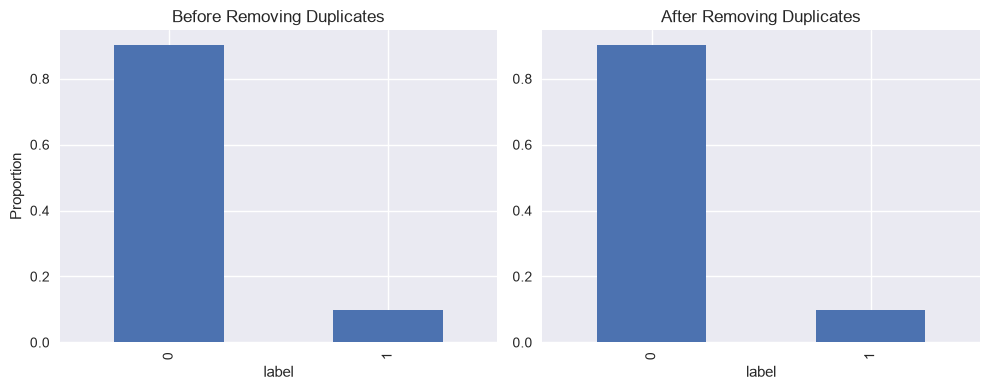

In [18]:
before = df['label'].value_counts(normalize=True)
after = df.drop_duplicates()['label'].value_counts(normalize=True)

fig, ax = plt.subplots(1, 2, figsize=(10,4))

before.plot(kind='bar', ax=ax[0], title="Before Removing Duplicates", ylabel="Proportion")
after.plot(kind='bar', ax=ax[1], title="After Removing Duplicates")

plt.tight_layout()
plt.show()

A comparison of target variable distribution before and after duplicate removal

### Handling Missing Values ###

The dataset contains missing values in existing conditions. However, for a medical dataset it may be the case that the patient doesn't have existing conditions to begin with.
For this we will analyze corresponding columns, such as endoscopy abd biopsy result to the missing values.


In [20]:
df[df["existing_conditions"].isna()][
    [
        "existing_conditions",
        "endoscopic_images",
        "biopsy_results",
        "helicobacter_pylori_infection"
    ]
]

,existing_conditions,endoscopic_images,biopsy_results,helicobacter_pylori_infection
2,NaN,0,0,0
8,NaN,0,0,1
12,NaN,0,1,0
14,NaN,0,0,0
16,NaN,0,1,0
...,...,...,...,...
212318,NaN,1,0,0
212333,NaN,0,0,1
212334,NaN,0,1,0
212351,NaN,1,0,0


Above df shows that for some patients have cases of abnormal endoscopic images, positive biopsy results, and helocobater pylori infection despite none existing conditions.
Let's first obeserve the count of it

In [24]:
count_endoscopic = df[
    (df["existing_conditions"].isna()) &
    (df["endoscopic_images"] == 1)
].shape[0]

print(f"Number of patients for Abnormal Endoscopi images: {count_endoscopic}")

count_biopsy = df[
    (df["existing_conditions"].isna()) &
    (df["biopsy_results"] == 1)
].shape[0]

print(f"Number of patients with positive biopsy result: {count_biopsy}")

count_infection = df[
    (df["existing_conditions"].isna()) &
    (df["helicobacter_pylori_infection"] == 1)
].shape[0]

print(f"Number of patients with helicobacter pylori infection: {count_infection}")

Number of patients for Abnormal Endoscopi images: 12779
Number of patients with positive biopsy result: 4308
Number of patients with helicobacter pylori infection: 10653


The existing_conditions feature contains 42,486 missing values. An investigation of these records showed that 30.08% had abnormal endoscopic findings, 25.08% tested positive for Helicobacter pylori infection, and 10.14% had positive biopsy results. Since a considerable proportion of patients with missing values still exhibit clinically significant indicators, the missing values are unlikely to represent the absence of existing medical conditions. Therefore, the missing values will be treated as "Unknown" instead of "None" to avoid introducing misleading assumptions into the model.

In [25]:
missing_mask = df["existing_conditions"].isna()

print(pd.crosstab(missing_mask, df["label"], normalize="index") * 100)

label                        0          1
existing_conditions                      
False                90.168837   9.831163
True                 89.975521  10.024479


Additionally, the class distribution of the target variable is nearly identical between records with and without missing values (9.83% vs. 10.02% positive cases), suggesting that the missingness is not directly associated with gastric cancer diagnosis.

Filling missing values with "unknown"

In [26]:
df["existing_conditions"] = df["existing_conditions"].fillna("Unknown")

In [27]:
df.isna().sum()

age                              0
gender                           0
family_history                   0
smoking_habits                   0
alcohol_consumption              0
helicobacter_pylori_infection    0
dietary_habits                   0
existing_conditions              0
endoscopic_images                0
biopsy_results                   0
ct_scan                          0
mature_mirna_acc                 0
mature_mirna_id                  0
target_symbol                    0
target_entrez                    0
target_ensembl                   0
diana_microt                     0
elmmo                            0
microcosm                        0
miranda                          0
mirdb                            0
pictar                           0
pita                             0
targetscan                       0
predicted.sum                    0
all.sum                          0
label                            0
dtype: int64

One-hot encoding the existing category column

In [28]:
df = pd.get_dummies(
    df,
    columns=["existing_conditions"],
    drop_first=False
)

In [29]:
df.head()

,age,gender,family_history,smoking_habits,alcohol_consumption,helicobacter_pylori_infection,dietary_habits,endoscopic_images,biopsy_results,ct_scan,...,mirdb,pictar,pita,targetscan,predicted.sum,all.sum,label,existing_conditions_Chronic Gastritis,existing_conditions_Diabetes,existing_conditions_Unknown
0,43,1,1,0,0,0,0,0,0,0,...,0.561920,0.438175,0.283603,0.928244,4.324299,7.666791,0,True,False,False
1,86,0,1,0,0,1,1,0,0,0,...,0.985585,0.144609,0.375375,0.103573,7.967674,1.483280,0,False,True,False
2,68,1,0,1,1,0,1,0,0,0,...,0.905853,0.827279,0.350915,0.166878,3.748651,3.046783,0,False,False,True
3,57,0,0,0,0,1,1,0,0,0,...,0.429935,0.935231,0.794704,0.867036,5.478298,8.811307,0,True,False,False
4,33,1,0,1,1,0,1,1,0,0,...,0.650832,0.337669,0.427492,0.915804,1.809181,0.394632,0,False,True,False


Exporting the cleaned dataset

In [30]:
df.to_csv("../Dataset/cleaned_gcs_kushal.csv", index=False)